<a href="https://colab.research.google.com/github/Ferdaus71/Ostad-Module-16/blob/main/Module_16_Assignment_People_Flow_Detection_using_Object_Tracking_%26_Heatmap_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Required Libraries

In [3]:
!pip install -q ultralytics supervision opencv-python-headless

# Import Libraries

In [4]:
import cv2
import numpy as np
from ultralytics import YOLO
import supervision as sv
from collections import defaultdict
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload Video

In [5]:
uploaded = files.upload()

Saving people-walking.mp4 to people-walking.mp4


In [6]:
VIDEO_PATH = "people-walking.mp4"

# Load YOLOv8m Model

In [7]:
model = YOLO("yolov8m.pt")

# Video Information

In [8]:
video_info = sv.VideoInfo.from_video_path(VIDEO_PATH)

print(video_info)

VideoInfo(width=1920, height=1080, fps=25.0, total_frames=341)


# Initialize ByteTrack

In [9]:
tracker = sv.ByteTrack()

box_annotator = sv.BoxAnnotator()

label_annotator = sv.LabelAnnotator()

# Define Counting Lines

In [10]:
LINE_UP = 220
LINE_DOWN = 340

# Initialize Variables

In [11]:
memory = {}

entered = set()
exited = set()

in_count = 0
out_count = 0

heatmap = np.zeros(
    (video_info.height, video_info.width),
    dtype=np.float32
)

# Open Video

In [12]:
cap = cv2.VideoCapture(VIDEO_PATH)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    "output.mp4",
    fourcc,
    video_info.fps,
    (video_info.width, video_info.height)
)

# Main Detection Loop

In [13]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame, verbose=False)[0]

    detections = sv.Detections.from_ultralytics(results)

    detections = detections[detections.class_id == 0]

    detections = tracker.update_with_detections(detections)

    labels = []

    for i in range(len(detections)):

        tracker_id = detections.tracker_id[i]

        x1, y1, x2, y2 = detections.xyxy[i]

        center_x = int((x1 + x2) / 2)

        center_y = int((y1 + y2) / 2)

        labels.append(f"ID {tracker_id}")

        heatmap[center_y, center_x] += 1

        if tracker_id in memory:

            previous_y = memory[tracker_id]

            # IN
            if previous_y < LINE_UP and center_y >= LINE_UP:

                if tracker_id not in entered:

                    in_count += 1
                    entered.add(tracker_id)

            # OUT
            if previous_y > LINE_DOWN and center_y <= LINE_DOWN:

                if tracker_id not in exited:

                    out_count += 1
                    exited.add(tracker_id)

        memory[tracker_id] = center_y

    annotated = frame.copy()

    annotated = box_annotator.annotate(
        scene=annotated,
        detections=detections
    )

    annotated = label_annotator.annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )

    cv2.line(
        annotated,
        (0, LINE_UP),
        (video_info.width, LINE_UP),
        (0,255,0),
        3
    )

    cv2.line(
        annotated,
        (0, LINE_DOWN),
        (video_info.width, LINE_DOWN),
        (0,0,255),
        3
    )

    cv2.putText(
        annotated,
        f"IN : {in_count}",
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )

    cv2.putText(
        annotated,
        f"OUT : {out_count}",
        (20,80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,0,255),
        2
    )

    writer.write(annotated)

# Close Video

In [14]:
cap.release()
writer.release()

print("Video Saved Successfully")

Video Saved Successfully


# Generate Heatmap

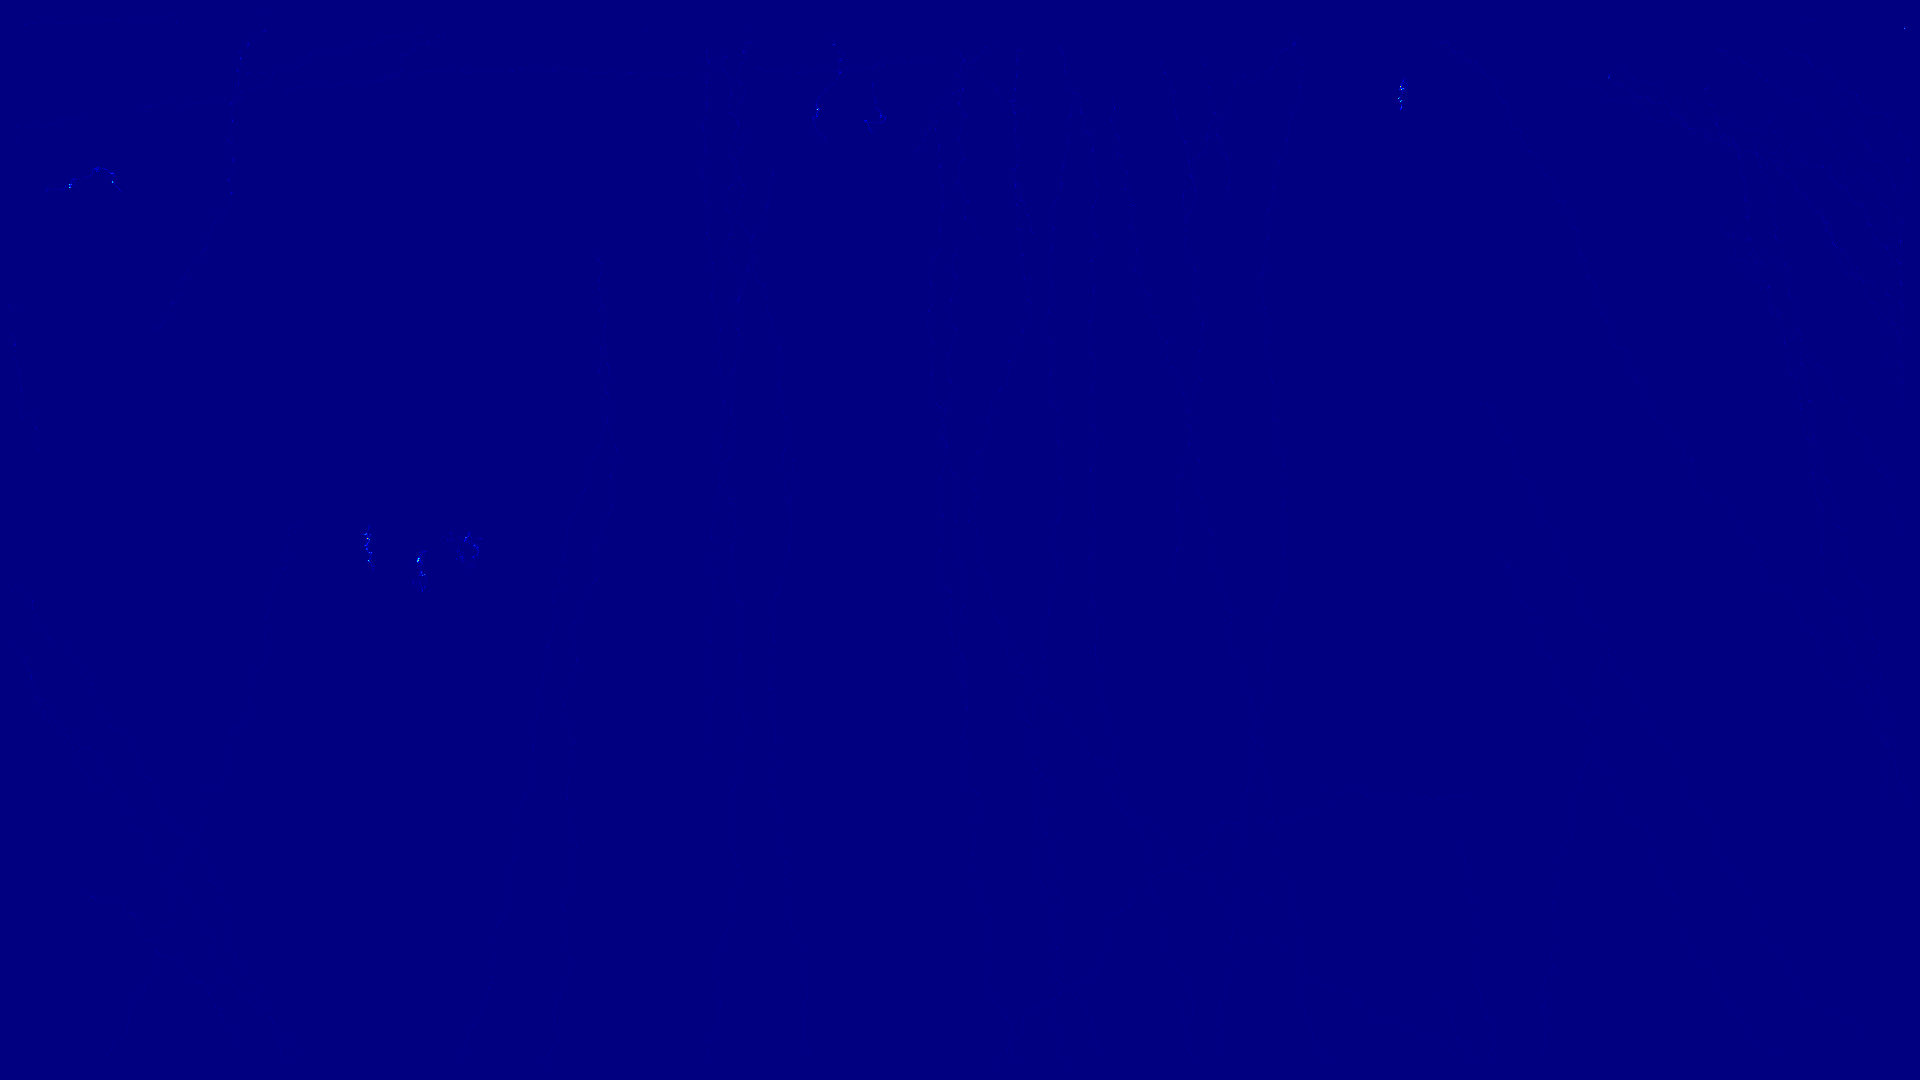

In [15]:
heatmap = cv2.normalize(
    heatmap,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

heatmap = heatmap.astype(np.uint8)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

cv2.imwrite("heatmap.png", heatmap)

cv2_imshow(heatmap)

# Heatmap Overlay

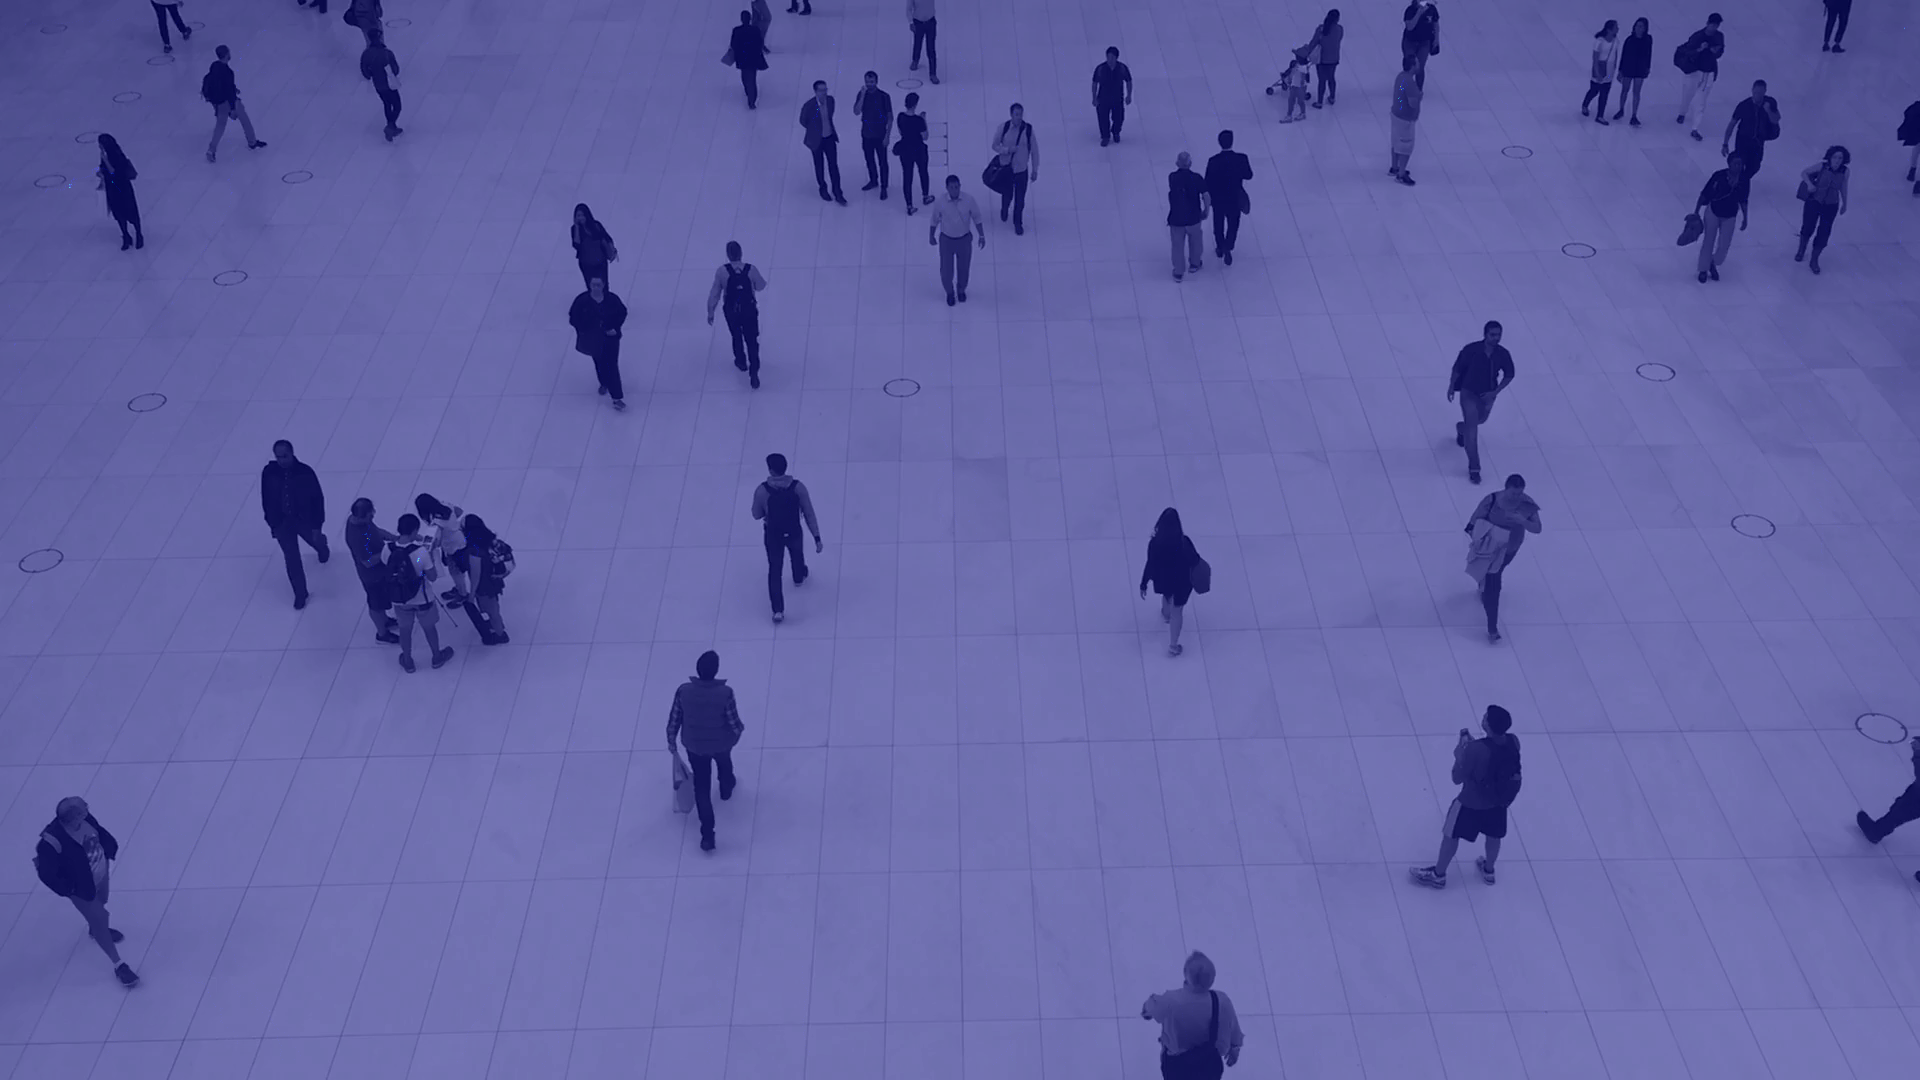

In [16]:
cap = cv2.VideoCapture(VIDEO_PATH)

ret, frame = cap.read()

overlay = cv2.addWeighted(
    frame,
    0.5,
    heatmap,
    0.5,
    0
)

cv2.imwrite(
    "heatmap_overlay.png",
    overlay
)

cv2_imshow(overlay)

cap.release()

# Download Results

In [17]:
files.download("output.mp4")

files.download("heatmap.png")

files.download("heatmap_overlay.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>